In [18]:
import numpy as np
from scipy.integrate import solve_ivp
import networkx as nx
import matplotlib.pyplot as plt
import src


In [19]:
# NEURON PARAMETERS
A = 1
DELTA = 0.03  # 0.02
GAMMA = 0.5
ETA = 0.01
G = 2

In [20]:
# GRAPH SIZE 
N = 1

In [21]:
# TIMESCALE
T = 3
T_N = 100
t_eval = np.linspace(0, T, T_N)

In [22]:
# INITIAL CONDITIONS
ic = np.zeros(N * 2)
ic[0] = 0.3

In [23]:
L = np.zeros((1, 1))

In [24]:
def fun_system(t, y):
    d = int(len(y) / 2)
    v = y[0:d]
    n = y[d:]

    dv = (A * v * (DELTA - v) * (v - 1) - n) / ETA - G * np.matmul(L, v)
    dn = - GAMMA * n + v

    return np.concatenate([dv, dn])

In [25]:
# Solve the initial value problem
sol = solve_ivp(fun_system, [0, T], ic, t_eval=t_eval)

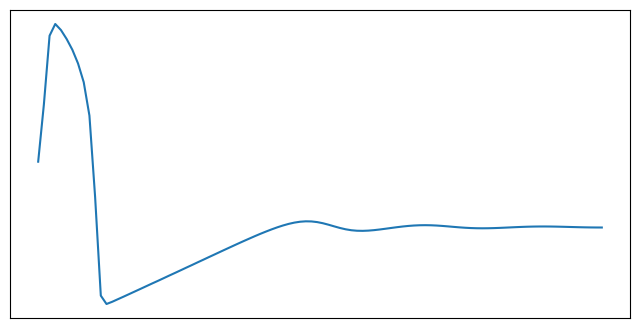

In [29]:
# A SINGLE NEURON
f, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(sol.t, sol.y[0, :], label='v(t)')
# ax.grid()
# ax.set_yticklabels([])
# ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])
f.savefig('figs/single_neuron.png')

In [10]:
# GRAPH SIZE 
N = 8

In [11]:
# TIMESCALE
T = 3
T_N = 100
t_eval = np.linspace(0, T, T_N)

In [12]:
# INITIAL CONDITIONS
ic = np.zeros(N * 2)
ic[0] = 0.3

In [13]:
# GENERATE GRAPH
g = nx.cycle_graph(N, create_using=nx.DiGraph)

L = src.laplacian_matrix(g)

In [14]:
# Solve the initial value problem
sol = solve_ivp(fun_system, [0, T], ic, t_eval=t_eval)

In [16]:
# Show the outputs
animator = src.MakeAnimation(g, sol=sol, layout_type='circular')
animator.save('figs/neuron_circle.gif')

MovieWriter imagemagick unavailable; using Pillow instead.


![Neuron Animation](figs/neuron_circle.gif)

In [10]:
# NEURON PARAMETERS
A = 2
DELTA = 0.00001  # 0.02
GAMMA = .1
ETA = 0.01
G = 1

In [11]:
# GRAPH SIZE
N = 200

In [12]:
# TIMESCALE
T = 10
T_N = 100
t_eval = np.linspace(0, T, T_N)

In [13]:
# INITIAL CONDITIONS
ic = np.zeros(N * 2)
ic[0:10] = 0.3

In [ ]:
# GENERATE GRAPH
g = nx.random_k_out_graph(n=N, k=2, alpha=.8, self_loops=False, seed=42)
    
L = src.laplacian_matrix(g)

In [15]:
# Solve the initial value problem
sol = solve_ivp(fun_system, [0, T], ic, t_eval=t_eval)

In [16]:
animator = src.MakeAnimation(g, sol=sol)
animator.save('figs/neuron_200.gif')

MovieWriter imagemagick unavailable; using Pillow instead.


![Neuron Animation](figs/neurons_200.gif)